In [13]:
using Plots,JLD2,LinearAlgebra

In [14]:
Nx=10
Ny=10
tper=0.37

tpa=2.0
tNNN=0.16

α=-1.2

β=-1.2
K=1.0;
KNNN=1.0;

filling=1.25
#trytime=1

1.25

In [15]:
st=load("10Nx10Ny0.37tper2.0tpa0.16tNNN-1.2alpha-1.2beta1.0K1.0KNNN1.25filling1try2seed.jld2")
   

Dict{String, Any} with 13 entries:
  "relevant_qset"       => [[3, 7, 1], [3, 7, 2], [3, 3, 1], [3, 3, 2]]
  "relevant_qamplitude" => ComplexF64[0.770175+0.301114im, 0.770174+0.301115im,…
  "Eelec"               => -2.4619
  "spectrum"            => [-4.74, -4.74, -4.61618, -4.61618, -4.61577, -4.6157…
  "max_record"          => 0.321602
  "average_record"      => 0.22361
  "orbital_id"          => [1 11 … 81 91; 2 12 … 82 92; … ; 9 19 … 89 99; 10 20…
  "phonon_id"           => [1 11 … 81 91; 2 12 … 82 92; … ; 9 19 … 89 99; 10 20…
  "FL"                  => 1.59816
  "phonon_coor"         => [0.237517, 0.00511388, -0.240677, 0.143633, 0.151907…
  "ave_npa"             => 125.0
  "E_total"             => -2.39029
  "Egap"                => 0.175016

In [25]:
abs.(st[ "relevant_qamplitude"])

4-element Vector{Float64}:
 0.8269453459238902
 0.8269451607877446
 0.826945344651624
 0.8269451372366625

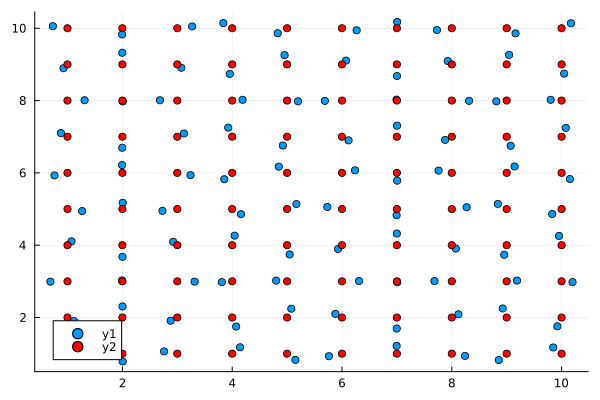

In [16]:
phonon_coor=st["phonon_coor"]
phonon_id=st["phonon_id"]
atom_x=zeros(Float64,Nx,Ny)
atom_y=zeros(Float64,Nx,Ny)
dis_x=zeros(Float64,Nx,Ny)
dis_y=zeros(Float64,Nx,Ny)

for ja in 1:Nx, jb in 1:Ny
    atom_x[ja,jb]=ja
    atom_y[ja,jb]=jb
    dis_x[ja,jb]=phonon_coor[phonon_id[ja,jb,1]]+ja
    dis_y[ja,jb]=phonon_coor[phonon_id[ja,jb,2]]+jb
    
end
#COM_x=sum(dis_x)/(Nx*Ny)
#COM_y=sum(dis_y)/(Nx*Ny)
#dis_x=dis_x .- COM_x
#dis_y=dis_y .- COM_y
#quiver(vec(atom_x),vec(atom_y),quiver=(0.5*vec(dis_x),0.5*vec(dis_y)))

scatter(vec(dis_x),vec(dis_y))
scatter!(vec(atom_x),vec(atom_y),color=:red)


In [17]:
sort(vec(dis_y)-vec(atom_y))

100-element Vector{Float64}:
 -0.32159806667079316
 -0.32159806667079316
 -0.3054932937561814
 -0.3054932937561814
 -0.26402332565689157
 -0.26402332565689157
 -0.2563332769327076
 -0.25633327693270713
 -0.2508017404459775
 -0.25080174044597703
  ⋮
  0.25080174044597703
  0.2563332769327058
  0.2563332769327067
  0.26402332565689157
  0.26402332565689157
  0.3054932937561814
  0.3054932937561814
  0.32159806667079316
  0.32159806667079316

In [18]:
sort(vec(sqrt.(dis_x.^2+dis_y.^2)))

100-element Vector{Float64}:
  1.6363164602368825
  2.15335117748522
  2.205098869714719
  2.956723677171801
  3.0537864605956755
  3.0696584674329115
  3.4555785311062683
  3.623568348312361
  4.187710129019972
  4.243457971178839
  ⋮
 12.062755528853273
 12.351687562299492
 12.409865613005975
 12.599794445687365
 12.664449663019914
 12.946694710253492
 13.318616857943075
 13.457742600818904
 14.359992543477246

In [19]:
sum(vec(sqrt.(dis_x.^2+dis_y.^2)))/(Nx*Ny)

8.302463487131437

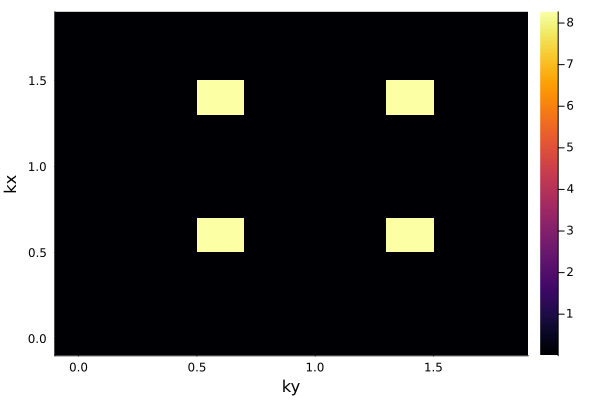

In [20]:
kx_space=2π*collect(0:1:Nx-1)/Nx
ky_space=2π*collect(0:1:Ny-1)/Ny
Fourier_mode=zeros(ComplexF64,length(kx_space),length(ky_space))
for ja in eachindex(kx_space), jb in eachindex(ky_space)
    kx=kx_space[ja]
    ky=ky_space[jb]
    for jc in 1:Nx, jd in 1:Ny, xp in -0:0, yp in -0:0
    Fourier_mode[ja,jb]+=phonon_coor[phonon_id[jc,jd,2]]*exp(-im*(kx*(jc+xp*Nx)+ky*(jd+yp*Ny)))
    end

end

heatmap(ky_space/pi,kx_space/pi,abs.(Fourier_mode),xlabel="ky",ylabel="kx")

In [21]:
abs.(Fourier_mode)

0.5050762722761054

In [22]:
findmax(abs.(Fourier_mode))

(8.269451607877446, CartesianIndex(4, 8))

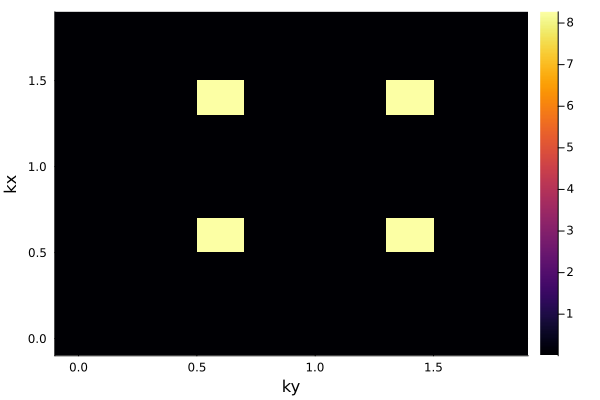

In [23]:
kx_space=2π*collect(0:1:Nx-1)/Nx
ky_space=2π*collect(0:1:Ny-1)/Ny
Fourier_mode=zeros(ComplexF64,length(kx_space),length(ky_space))
for ja in eachindex(kx_space), jb in eachindex(ky_space)
    kx=kx_space[ja]
    ky=ky_space[jb]
    for jc in 1:Nx, jd in 1:Ny, xp in -0:0, yp in -0:0
    Fourier_mode[ja,jb]+=phonon_coor[phonon_id[jc,jd,1]]*exp(-im*(kx*(jc+xp*Nx)+ky*(jd+yp*Ny)))
    end

end

heatmap(ky_space/pi,kx_space/pi,abs.(Fourier_mode),xlabel="ky",ylabel="kx")

In [24]:
findmax(abs.(Fourier_mode))

(8.269453459238907, CartesianIndex(8, 4))